### Phase vs. amplitude encoding in the whole-brain Stuart–Landau model

This notebook reproduces **Figure 4** by simulating a 29-area whole-brain network of Stuart–Landau oscillators (Markov et al. 2014 structural connectivity) and computing pairwise and higher-order (2-plet / 3-plet) PID across edges.

**Workflow:**
1. Configure environment and imports.
2. Load anatomical connectivity (FLN matrix, hierarchy, cortical area positions).
3. Set up simulation parameters and the Gaussian coupling profile.
4. Run the trial-wise simulation and store results.
5. Compute pairwise MI (amplitude vs. phase) for each area pair.
6. Compute higher-order redundancy and synergy across edge-pairs (2-plets and 3-plets).
7. Assemble and export the figure.

#### 1) Environment setup

In [1]:
import os
import sys

sys.path.insert(1, os.path.join("/", *os.getcwd().split("/")[:-1]))

In [2]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plot
import scipy
import xarray as xr
from frites.core import copnorm_nd
from hoi.core import get_mi
from mne.time_frequency import tfr_array_morlet, tfr_array_multitaper
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

from src.models import simulate

/home/INT/brovelli.a/.local/lib/python3.10/site-packages/tqdm-4.67.1-py3.10.egg/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
jax.config.update("jax_platform_name", "cpu")

In [4]:
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

#### 2) Anatomical data — Markov et al. (2014)

Load the 29-area macaque FLN (fraction of labelled neurons) matrix and cortical hierarchy values. `xy` contains 2-D pixel coordinates for each area on the flatmap used in Panel A. `sel_area_names` is the 7-area subset for higher-order analysis.

In [5]:
area_names = [
    "V1",
    "V2",
    "V4",
    "DP",
    "MT",
    "8m",
    "5",
    "8l",
    "TEO",
    "2",
    "F1",
    "STPc",
    "7A",
    "46d",
    "10",
    "9/46v",
    "9/46d",
    "F5",
    "TEpd",
    "PBr",
    "7m",
    "7B",
    "F2",
    "STPi",
    "PROm",
    "F7",
    "8B",
    "STPr",
    "24c",
]

In [6]:
xy = [
    (40, 364),
    (76, 298),
    (112, 367),
    (145, 161),
    (166, 319),
    (475, 194),
    (245, 146),
    (455, 209),
    (118, 449),
    (279, 300),
    (329, 124),
    (171, 300),
    (173, 142),
    (604, 206),
    (689, 263),
    (497, 248),
    (524, 206),
    (396, 309),
    (221, 533),
    (265, 413),
    (243, 100),
    (213, 239),
    (486, 82),
    (247, 435),
    (423, 397),
    (585, 134),
    (604, 147),
    (335, 489),
    (555, 191),
]

In [7]:
sel_area_names = ["V1", "V2", "V4", "8m", "7A", "9/46d", "24c"]

In [8]:
data = np.load("../interareal/markov2014.npy", allow_pickle=True).item()

Nareas = 29
flnMat = data["FLN"]                    # FLN[i,j]: fraction of neurons projecting from j to i
h = np.squeeze(data["Hierarchy"].T)     # cortical hierarchy index per area

eta = 0  # hierarchy scaling disabled (set > 0 to weight FLN by hierarchy gradient)

#### 3) Simulation parameters and coupling profile

Same Gaussian profile as Figure 3 (8 carrier cycles wide, 0–0.4 s). External input is injected only into area 0 (V1); all other areas receive indirect drive through the FLN connectivity.

In [9]:
ntrials = 1000
dt = 1e-4
fsamp = 1 / dt            # 10 kHz
time = np.arange(-4, 2, 1 / fsamp)
beta = 1e-4
Npoints = len(time)
decim = 20                # 10 kHz → 500 Hz
f = 40                    # Hz, same natural frequency for all 29 nodes

# modulate FLN by hierarchy; eta=0 leaves FLN unchanged
flnMat = (1 + eta * h)[:, np.newaxis] * flnMat

seeds = np.random.randint(0, 10000, ntrials)

In [10]:
s = 8 / (2 * np.pi * f)

time_start = 0
time_end = 0.4
timestim = time[(time > time_start) & (time < time_end)] - (time_end - time_start) / 2
ind = np.where((time > time_start) & (time < time_end))[0]
gaussian = np.exp(-(timestim**2) / (2 * s**2))
coupling = np.zeros_like(time)
coupling[ind] = gaussian

# Coupling strength array (linearly spaced from 1 to 100)
CS = np.linspace(1, 100, ntrials)
seeds = np.random.randint(0, 100000, ntrials)

In [11]:
coupling = CS[:, None] * coupling

In [12]:
# Iext prepared but passed as None to simulate() — external drive disabled in this run
Iext = np.zeros((ntrials, Nareas, len(time)))
Iext[:, 0] = coupling  # drive injected at V1 only

In [13]:
T_out = len(time[::decim])
out = np.empty((ntrials, Nareas, T_out), dtype=np.complex128)

for trial in tqdm(range(ntrials)):
    out[trial] = np.asarray(
        simulate(
            flnMat,
            coupling[trial],
            f,
            -5,
            fsamp,
            beta,
            Npoints,
            None,
            seeds[trial],
            decim=decim,
        )
    )

100%|██████████| 1000/1000 [07:31<00:00,  2.22it/s]


#### 5) Convert simulation output to xarray and compute MI

Wrap the stacked output in a labelled `DataArray` (trials × roi × times) cropped to [−2, 2] s. Then vmap GC-MI over time for every area pair (area 0 vs. each of the other 28).

In [14]:
data = xr.DataArray(
    np.stack(out),
    dims=("trials", "roi", "times"),
    coords=(range(ntrials), area_names, time[::decim]),
).sel(times=slice(-2, 2))

In [15]:
labels = np.tile(np.expand_dims(CS, 1), data.sizes["times"])

In [16]:
mi_fcn = get_mi("gc")
mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2, None, None))

In [17]:
I_S_R1 = []
I_S_R2 = []
I_S_R1_R2 = []
for i in tqdm(range(1, Nareas)):

    z = data.isel(roi=0) * np.conj(data.isel(roi=i))
    A = np.abs(z).values
    dphi = np.angle(z)
    # dphi = np.unwrap(dphi)
    dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)
    mv = np.stack((A, dphi), axis=0)

    I_S_R1 += [mi_fcn_time(A[None], labels[None], False, True)]
    I_S_R2 += [mi_fcn_time(dphi[None], labels[None], False, True)]
    I_S_R1_R2 += [mi_fcn_time(mv, labels[None], False, True)]

100%|██████████| 28/28 [00:52<00:00,  1.88s/it]


In [18]:
I_S_R1 = np.stack(I_S_R1)
I_S_R2 = np.stack(I_S_R2)
I_S_R1_R2 = np.stack(I_S_R1_R2)

In [19]:
def plot_mutual_info(ax1, ax2, ax3, pos):
    plt.sca(ax1)

    plt.plot(z_data[-1].times, I_S_R1_R2[pos])
    plt.plot(z_data[-1].times, I_S_R1[pos])
    plt.plot(z_data[-1].times, I_S_R2[pos])

    plt.legend(
        [
            r"I($A, \Delta\theta$; Y)",
            r"I($A$; Y)",
            r"I($\Delta\theta$; Y)",
        ],
        frameon=False,
        loc="upper center",
    )

    plt.ylabel("[bits]")
    plt.xlabel("Time [s]")
    plt.xlim(-0.5, 1)
    plt.ylim(-0.05, I_S_R1_R2[pos].max() + 0.05)

    [ax1.spines[key].set_visible(False) for key in ["top", "right"]]

    plt.sca(ax2)

    red = np.minimum(I_S_R2[pos], I_S_R1[pos])
    syn = I_S_R1_R2[pos] - np.maximum(I_S_R2[pos], I_S_R1[pos])

    plt.plot(data.times, red)
    plt.plot(data.times, syn)

    plt.legend(
        [
            r"R($A, \Delta\theta$)",
            r"S($A, \Delta\theta$)",
        ],
        frameon=False,
        loc="upper center",
    )

    [ax2.spines[key].set_visible(False) for key in ["top", "right"]]
    plt.xlabel("Time [s]")
    plt.xlim(-0.5, 1)
    plt.ylim(-0.05, I_S_R1_R2[pos].max() + 0.05)

    plt.sca(ax3)

    plt.plot(data.times, I_S_R1[pos] - red)
    plt.plot(data.times, I_S_R2[pos] - red)

    plt.legend(
        [
            r"U[$A$]",
            r"U[$\Delta\theta$]",
        ],
        frameon=False,
        loc="upper center",
    )
    plt.xlabel("Time [s]")
    plt.xlim(-0.5, 1)
    plt.ylim(-0.05, I_S_R1_R2[pos].max() + 0.05)

    [ax3.spines[key].set_visible(False) for key in ["top", "right"]]

#### 6) Higher-order phase interactions (2-plets and 3-plets)

For the 7-area subset, build all pairwise phase-difference edges (21 edges for C(7,2)). Feed them into `RedundancyMMI` / `SynergyMMI` per time point to find edge-pairs (2-plets) and edge-triplets (3-plets) with significant redundant or synergistic HOI.

In [20]:
from hoi.metrics import RedundancyMMI, SynergyMMI

In [21]:
area_indices = []
for i in range(Nareas):
    if area_names[i] in sel_area_names:
        area_indices.append(i)
nSelAreas = len(area_indices)

In [22]:
edges = []

In [23]:
roi_st = []
dh_ij = []
for i in range(nSelAreas):
    for j in range(i + 1, nSelAreas):
        s, t = area_indices[i], area_indices[j]
        phi = np.angle(data[:, s] * np.conj(data[:, t]))
        phi = np.abs((phi + np.pi) % (2 * np.pi) - np.pi)
        edges += [phi]
        roi_st += [f"{area_names[s]}-{area_names[t]}"]
        dh_ij += [np.abs(h[s] - h[t])]

In [24]:
dh_ij = np.stack(dh_ij)

In [29]:
edges = np.stack(edges, 1)

In [30]:
edges.shape #1000, 21, 2000

(1000, 21, 2000)

In [31]:
model_red = RedundancyMMI(edges, np.arange(ntrials))

model_syn = SynergyMMI(edges, np.arange(ntrials))

In [32]:
red = model_red.fit(minsize=2, maxsize=2, method="gc")
syn = model_syn.fit(minsize=2, maxsize=2, method="gc")

    Copnorm and demean the data
Get list of multiplets
  0%|          |  0/1 [00:00<?,       ?it/s]/home/INT/brovelli.a/.local/lib/python3.10/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
    Copnorm and demean the data                                 
Get list of multiplets


#### 7) Select significant multiplets and assemble figure

In [38]:
indexes = model_red.multiplets[
    np.logical_and(np.nanmean(red, 1) > 0.0008, np.nanmean(syn, 1) > 0.0005)
]

for i, j in indexes:
    print(f"{roi_st[i]} - {roi_st[j]}")

V1-V2 - V1-V4
V1-V2 - V2-V4
V1-V2 - 8m-9/46d
V1-V4 - V2-V4
V1-V4 - 8m-9/46d
V2-V4 - 8m-9/46d


In [39]:
sel_2plets = np.where(
    np.logical_and(np.nanmean(red, 1) > 0.0008, np.nanmean(syn, 1) > 0.0005)
)[0][-2:]

In [40]:
red3 = model_red.fit(minsize=3, maxsize=3, method="gc")
syn3 = model_syn.fit(minsize=3, maxsize=3, method="gc")

    Copnorm and demean the data
Get list of multiplets
  0%|          |  0/1 [00:00<?,       ?it/s]/home/INT/brovelli.a/.local/lib/python3.10/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
    Copnorm and demean the data                                 
Get list of multiplets


In [43]:
sel_2plets  =np.where( np.logical_and(np.nanmean(red, 1) > 0.0008, np.nanmean(syn, 1) > 0.0005) ) [0][-2:]

In [44]:
red3 = model_red.fit(minsize=3, maxsize=3, method="gc")
syn3 = model_syn.fit(minsize=3, maxsize=3, method="gc")

    Copnorm and demean the data
Get list of multiplets
    Copnorm and demean the data                                 
Get list of multiplets


In [45]:
indexes = model_red.multiplets[
    np.logical_and(np.nanmean(red3, 1) > 0.002, np.nanmean(syn3, 1) > 0.002)
]

for i, j, k in indexes:
    print(f"{roi_st[i]} - {roi_st[j]} - {roi_st[k]}")

In [46]:
indexes = model_red.multiplets[
    np.logical_and(np.nanmean(red3, 1) > 0.0004, np.nanmean(syn3, 1) > 0.0004)
]

for i, j, k in indexes:
    print(f"{roi_st[i]} - {roi_st[j]}  - {roi_st[k]}")

V1-V2 - V1-V4  - 8m-9/46d
V1-V2 - V2-V4  - 8m-9/46d
V1-V4 - V2-V4  - 8m-9/46d


In [47]:
sel_3plets  =np.where( np.logical_and(np.nanmean(red3, 1) > 0.0004, np.nanmean(syn3, 1) > 0.0004) ) [0][-2:]

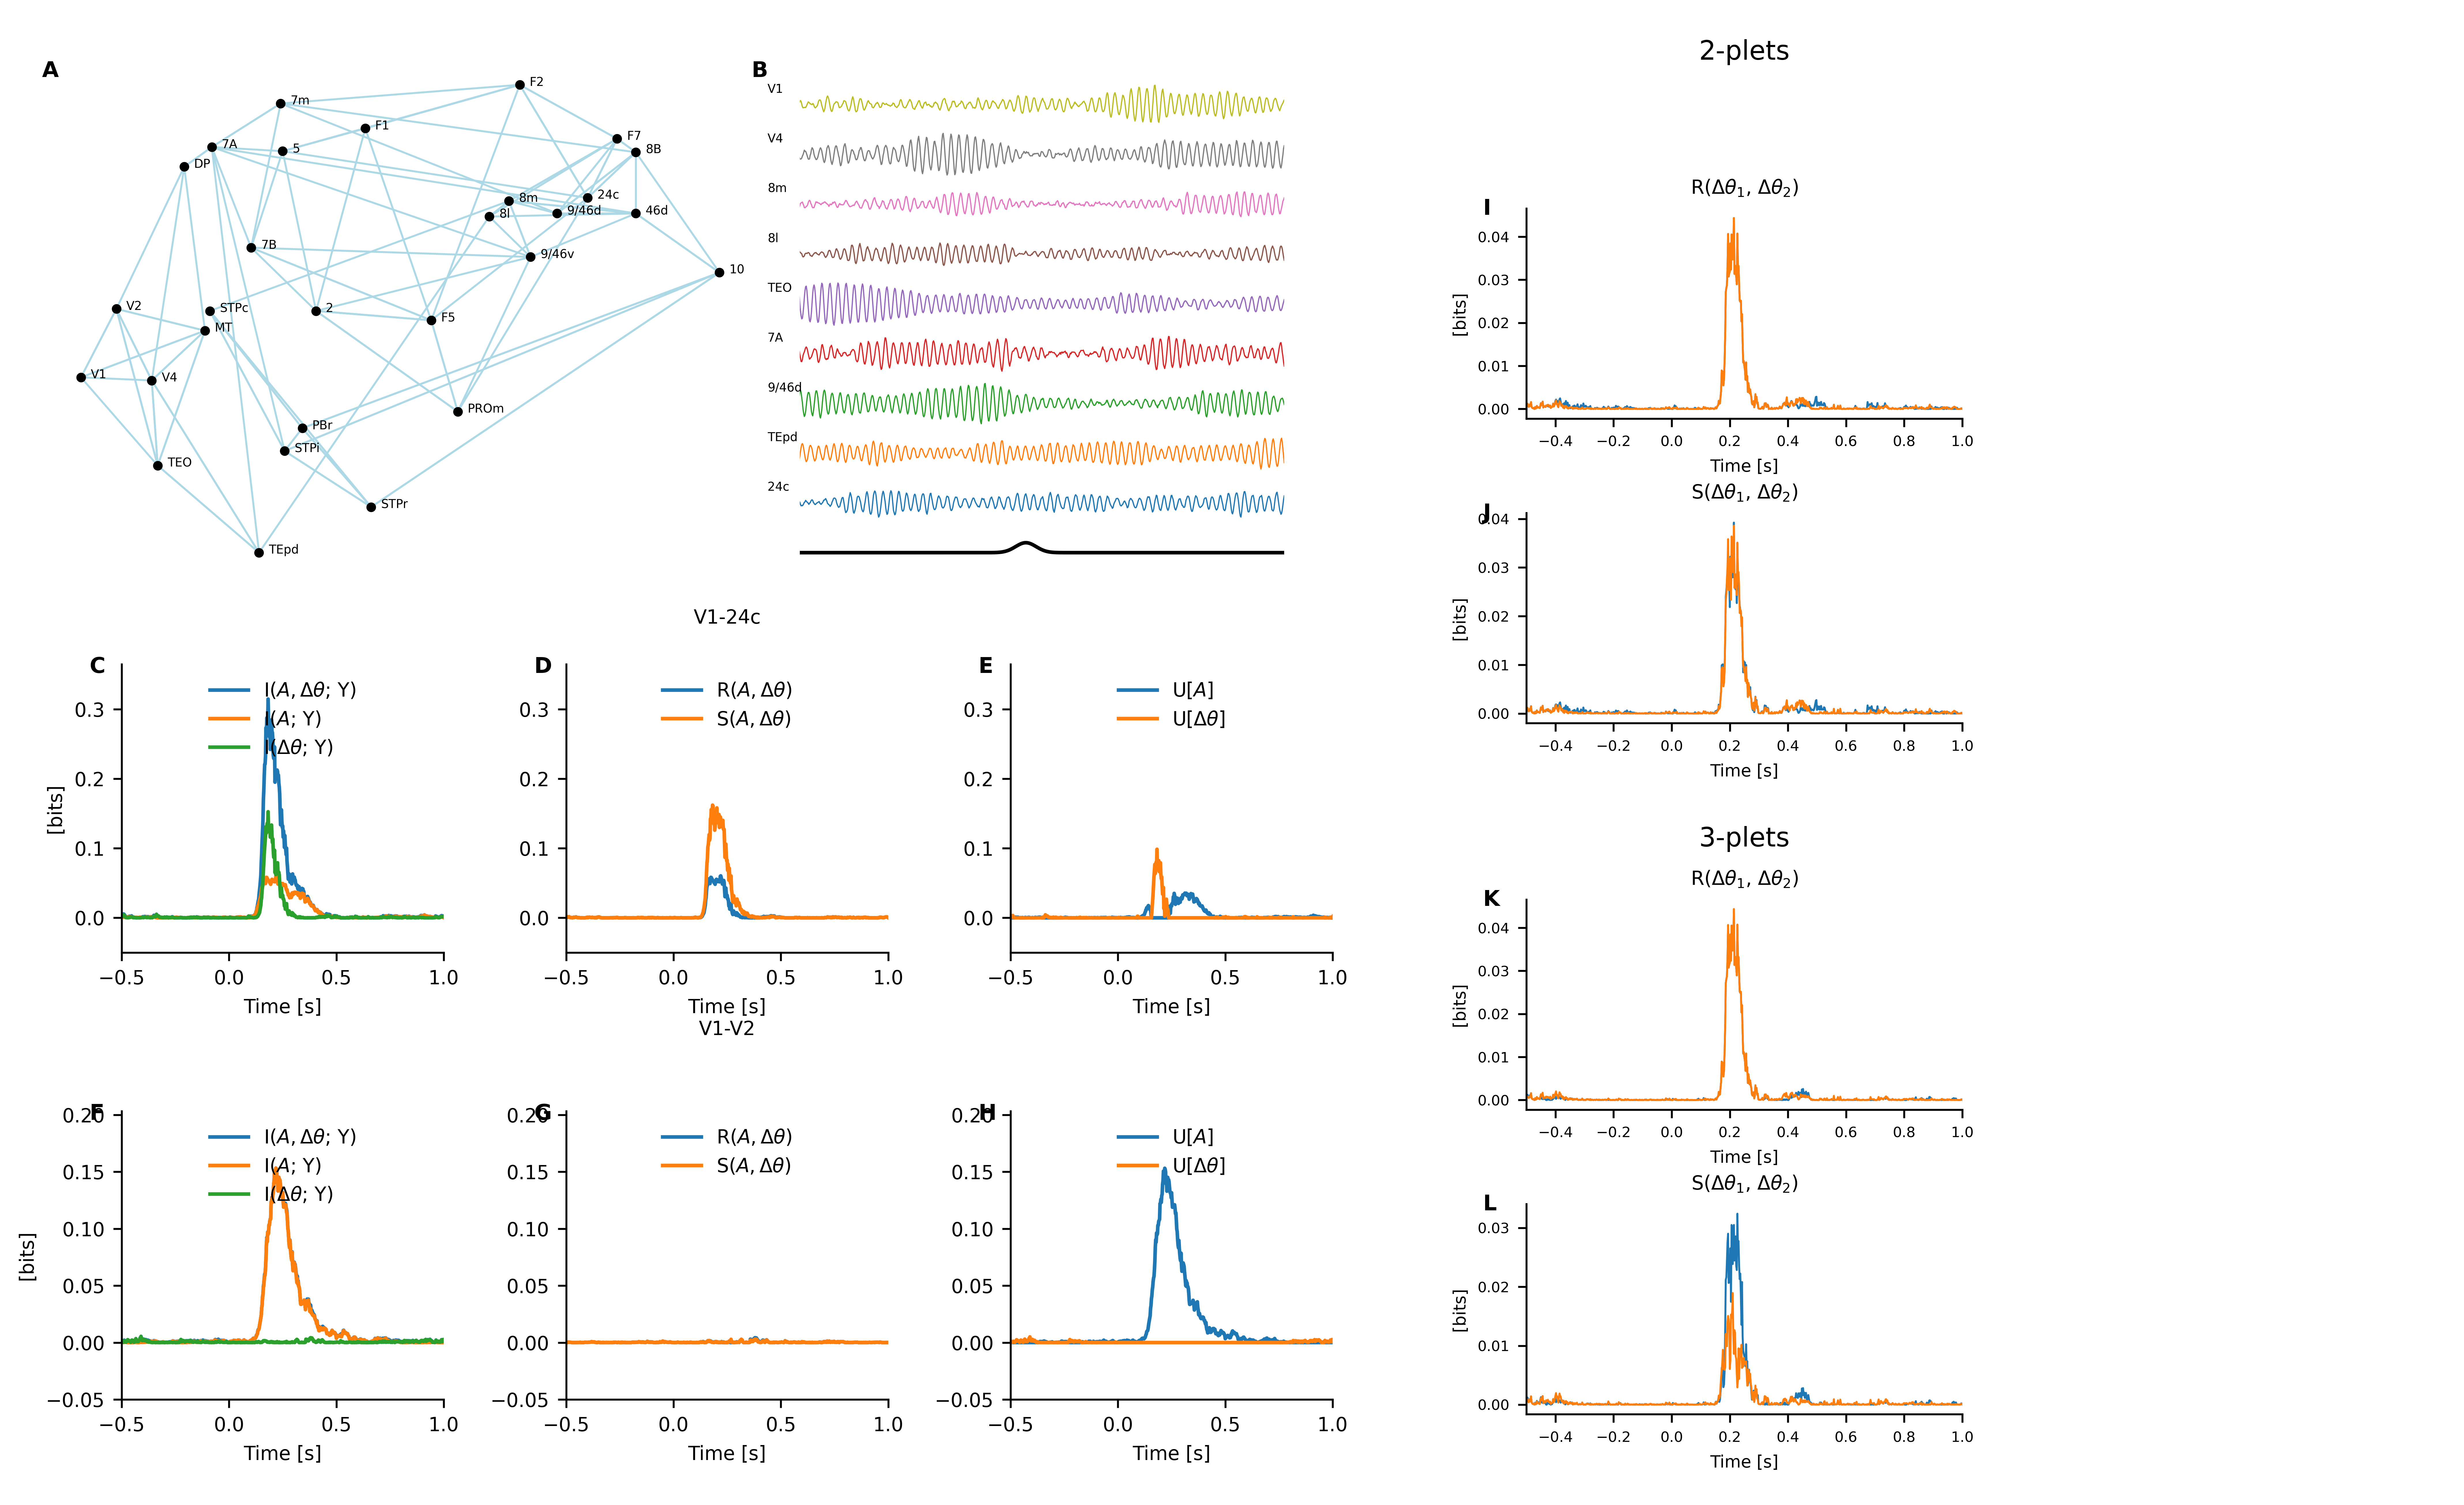

In [48]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(14.0, 8.5), dpi=600)

# Panel A - brain network graph (top-left)
gs1 = fig.add_gridspec(nrows=1, ncols=1, left=0.01, right=0.30, bottom=0.62, top=0.97)

# Panel B - time series (top-middle)
gs2 = fig.add_gridspec(nrows=1, ncols=1, left=0.32, right=0.52, bottom=0.62, top=0.97)

# Panels C-H: 2 rows x 3 cols (bottom-left block)
gs3 = fig.add_gridspec(
    nrows=2, ncols=3, left=0.04, right=0.54,
    bottom=0.06, top=0.56, hspace=0.55, wspace=0.38
)

# Right side: 2-plets (I) — 2 stacked plots
gs_i = fig.add_gridspec(
    nrows=2, ncols=1, left=0.62, right=0.80,
    bottom=0.52, top=0.87, hspace=0.45
)

# Right side: 3-plets (J) — 2 stacked plots
gs_j = fig.add_gridspec(
    nrows=2, ncols=1, left=0.62, right=0.80,
    bottom=0.05, top=0.4, hspace=0.45
)

# Panel A
ax1 = plt.subplot(gs1[0])

# Panel B
ax2 = plt.subplot(gs2[0])

# Panels C-H (row 0 = C,D,E; row 1 = F,G,H)
ax3 = plt.subplot(gs3[0, 0])  # C
ax4 = plt.subplot(gs3[0, 1])  # D
ax5 = plt.subplot(gs3[0, 2])  # E
ax6 = plt.subplot(gs3[1, 0])  # F
ax7 = plt.subplot(gs3[1, 1])  # G
ax8 = plt.subplot(gs3[1, 2])  # H

# Panel I: 2-plets — R (top) and S (bottom)
ax9  = plt.subplot(gs_i[0])   # I top: R(Δθ1, Δθ2)
ax10 = plt.subplot(gs_i[1])   # I bottom: S(Δθ1, Δθ2)

# Panel J: 3-plets — R (top) and S (bottom)
ax11 = plt.subplot(gs_j[0])   # J top: R(Δθ1, Δθ2)
ax12 = plt.subplot(gs_j[1])   # J bottom: S(Δθ1, Δθ2)

# ── "2-plets" and "3-plets" super-titles ──────────────────────────────────────
fig.text(0.71, 0.985, "2-plets", ha="center", va="top", fontsize=11, fontweight="normal")
fig.text(0.71, 0.45, "3-plets", ha="center", va="top", fontsize=11, fontweight="normal")

# ── Row labels between C-E and F-H panels ────────────────────────────────────
# "V1-24c" sits above row 0 of gs3 (panels C-E)
fig.text(0.29, 0.585, "V1-24c", ha="center", va="bottom", fontsize=8)
# "V1-V2" sits above row 1 of gs3 (panels F-H)
fig.text(0.29, 0.305, "V1-V2",  ha="center", va="bottom", fontsize=8)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL A — brain network graph
# ══════════════════════════════════════════════════════════════════════════════
plt.sca(ax1)
mask = flnMat > np.quantile(flnMat, 0.87, axis=1)[:, None]
for n in range(29):
    for j in np.where(mask[n])[0]:
        x1, y1 = xy[n]
        x2, y2 = xy[j]
        plt.plot([x1, x2], [y1, y2], "lightblue", lw=0.8)
for pos, (x_, y_) in enumerate(xy):
    plt.plot(x_, y_, "ko", ms=3)
    plt.text(x_ + 10, y_ + 1, area_names[pos], fontsize=5)
ax1.yaxis.set_inverted(True)
plt.axis("off")

# ══════════════════════════════════════════════════════════════════════════════
# PANEL B — oscillatory traces
# ══════════════════════════════════════════════════════════════════════════════
plt.sca(ax2)
z_data = (data - data.mean("times")) / data.std("times")
rois = ["24c", "TEpd", "9/46d", "7A", "TEO", "8l", "8m", "V4", "V1"]
for i, roi in enumerate(rois):
    plt.plot(z_data[-1].times, z_data[-1].values[i].real + (i * 5), lw=0.5)
    plt.text(-0.6, i * 5 + 1.2, roi, fontsize=5)
mask_t = (time >= -2) & (time <= 2)
plt.plot(time[mask_t], (Iext[-1, 0, mask_t] / 100 - 5), "k")
plt.axis("off")
plt.xlim(-0.5, 1)

# ══════════════════════════════════════════════════════════════════════════════
# PANELS C–E (row 0: V1-24c)
# ══════════════════════════════════════════════════════════════════════════════
plot_mutual_info(ax3, ax4, ax5, 0)   # first pair index

# ══════════════════════════════════════════════════════════════════════════════
# PANELS F–H (row 1: V1-V2)
# ══════════════════════════════════════════════════════════════════════════════
plot_mutual_info(ax6, ax7, ax8, -1)  # second pair index

# ══════════════════════════════════════════════════════════════════════════════
# PANEL I — 2-plets
# ══════════════════════════════════════════════════════════════════════════════
plt.sca(ax9)
plt.plot(data.times, red.T[:, sel_2plets], lw=0.8)
plt.title(r"R($\Delta\theta_{1}$, $\Delta\theta_{2}$)", fontsize=8)
[ax9.spines[k].set_visible(False) for k in ["top", "right"]]
plt.ylabel("[bits]", fontsize=7)
plt.xlabel("Time [s]", fontsize=7)
plt.xlim(-0.5, 1)
ax9.tick_params(labelsize=6)

plt.sca(ax10)
plt.plot(data.times, syn.T[:, sel_2plets], lw=0.8)
plt.title(r"S($\Delta\theta_{1}$, $\Delta\theta_{2}$)", fontsize=8)
[ax10.spines[k].set_visible(False) for k in ["top", "right"]]
plt.ylabel("[bits]", fontsize=7)
plt.xlabel("Time [s]", fontsize=7)
plt.xlim(-0.5, 1)
ax10.tick_params(labelsize=6)
# inset node diagrams go here if needed (ax10.inset_axes)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL J — 3-plets
# ══════════════════════════════════════════════════════════════════════════════
plt.sca(ax11)
plt.plot(data.times, red3.T[:, sel_3plets], lw=0.8)
plt.title(r"R($\Delta\theta_{1}$, $\Delta\theta_{2}$)", fontsize=8)
[ax11.spines[k].set_visible(False) for k in ["top", "right"]]
plt.ylabel("[bits]", fontsize=7)
plt.xlabel("Time [s]", fontsize=7)
plt.xlim(-0.5, 1)
ax11.tick_params(labelsize=6)

plt.sca(ax12)
plt.plot(data.times, syn3.T[:, sel_3plets], lw=0.8)
plt.title(r"S($\Delta\theta_{1}$, $\Delta\theta_{2}$)", fontsize=8)
[ax12.spines[k].set_visible(False) for k in ["top", "right"]]
plt.ylabel("[bits]", fontsize=7)
plt.xlabel("Time [s]", fontsize=7)
plt.xlim(-0.5, 1)
ax12.tick_params(labelsize=6)

# ══════════════════════════════════════════════════════════════════════════════
# Panel letters
# ══════════════════════════════════════════════════════════════════════════════
bg = plot.Background(visible=False)
plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12],
    fontsize=MEDIUM_SIZE,
    xpos=[-0.01] + [-0.10] * 11,
    ypos=[0.97] * 12,
)

plt.savefig("../figures/Figure4.pdf", bbox_inches="tight")

Figure 4: High-order interaction in the SL whole-brain model. (A) Structural connectivity derived from
the dataset reported in Markov et al. (2014). Here we show it as a binary network with only the top four
connections of each cortical area being drawn (FLN greater than the 87 percentile for each source area). (B)
The real part of the (Real(Z)) time-series for the simulated SL whole-brain model for selected 9 cortical areas
in one trial. The black time-series on the bottom show the global coupling dynamics g(t). The coupling
strength g among nodes was transiently modulated from 0 to 0.4 ms according to g(t) = 8Y/(2π f ), where
Y was the maximum coupling amplitude which was increased from 1 to 100 across trials (n = 1000). (C)
The time-series of the total mutual information between V1 and 24c carried by their joint amplitude A and
phase-difference ∆θ about the stimulus (blue curve). Only their amplitude interaction (orange curve), and
only their phase-difference (green). (D) The redundancy (blue curve) and synergy (orange curve) between
the joint amplitude and phase-difference concerning the stimulus. (E) The unique stimulus information
contained in the joint amplitude (orange curve), and only their phase-difference (green). (F-H) The same
as C-E but for areas V1 and V2. (I). High-order redundant (top panel) and synergistic (bottom panel)
information carried by pairs of edges via phase difference (∆θ1 and ∆θ2, respectively). The PID quantities are
computed for the phase-difference time-series between nodes i-j and l-k. The curves shown are for the two
disconnected edges (four nodes in total) with highest synergy and redundancy formed by the edges V1-V2
with 8m-7a (cyan) and V1-V4 and 8m-9/46d (green) (J) Oscillatory higher-order redundant (top panel) and
synergistic (bottom panel) information carried by three edges and five nodes.